In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
!pip install gymnasium numpy matplotlib

In [ ]:
"""
Setup Script for Air Raid DQN in Kaggle
Run this cell FIRST in your Kaggle notebook
"""

# Step 1: Install required packages
print("Installing required packages...")
print("="*60)

# Install gymnasium with Atari support
!pip install -q gymnasium[atari]
!pip install -q gymnasium[accept-rom-license]

# Alternative: Install ale-py directly
!pip install -q ale-py

# Install AutoROM for Atari ROMs (includes Air Raid)
!pip install -q autorom[accept-rom-license]

# Accept Atari ROM license and download ROMs
print("\nAccepting Atari ROM license and downloading ROMs...")
!AutoROM --accept-license

print("\n" + "="*60)
print("Installation complete!")
print("="*60)

# Step 2: Verify installation
print("\nVerifying installation...")
try:
    import gymnasium as gym
    from ale_py import ALEInterface
    print("✓ gymnasium installed")
    print("✓ ale-py installed")
    
    # Check if ALE namespace is available
    try:
        env = gym.make('ALE/AirRaid-v5', frameskip=1)
        print("✓ ALE/AirRaid-v5 environment available")
        print(f"  Action space: {env.action_space}")
        print(f"  Observation space: {env.observation_space}")
        env.close()
    except Exception as e:
        print(f"✗ Error creating environment: {e}")
        print("\nTrying alternative environment name...")
        try:
            env = gym.make('AirRaid-v5', frameskip=1)
            print("✓ AirRaid-v5 environment available (without ALE prefix)")
            env.close()
        except Exception as e2:
            print(f"✗ Also failed: {e2}")
    
except ImportError as e:
    print(f"✗ Import error: {e}")
    print("\nPlease restart the kernel and run this cell again.")

# Step 3: Import other dependencies
print("\nImporting other dependencies...")
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
print("✓ All dependencies imported successfully")

# Step 4: Check GPU availability
print(f"\nGPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Running on CPU (will be slower)")

print("\n" + "="*60)
print("Setup complete! You can now run the DQN code.")
print("="*60)

In [ ]:
# """
# Deep Q-Network (DQN) Agent for Air Raid (Atari)
# Author: [Your Name]
# Course: [Course Name]
# Date: October 2025

# License: MIT License
# Copyright (c) 2025 [Your Name]

# This implementation uses Deep Q-Learning with Convolutional Neural Networks
# to play the Atari game Air Raid. The architecture is based on the original
# DeepMind DQN paper (Mnih et al., 2015) with modern PyTorch implementation.

# Attribution:
# - DQN algorithm: Based on Mnih et al. (2015) "Human-level control through deep RL"
# - CNN architecture: Adapted from DeepMind's Nature paper
# - Experience replay: Standard implementation from DQN literature
# - Frame preprocessing: Common Atari preprocessing pipeline
# - All code implementation, experiments, and analysis: Original work

# References:
# - Mnih, V., et al. (2015). Human-level control through deep reinforcement learning. Nature.
# - Mnih, V., et al. (2013). Playing Atari with Deep Reinforcement Learning. NIPS Workshop.
# """

# import gymnasium as gym
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F
# from collections import deque, namedtuple
# import random
# import matplotlib.pyplot as plt
# from PIL import Image
# import time
# import pickle

# # Set device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# # Experience tuple for replay buffer
# Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])


# class FramePreprocessor:
#     """
#     Preprocesses Atari frames for DQN.
#     - Converts to grayscale
#     - Resizes to 84x84
#     - Normalizes pixel values
#     """
    
#     def __init__(self, height=84, width=84):
#         self.height = height
#         self.width = width
    
#     def preprocess(self, frame):
#         """
#         Preprocess a single frame.
        
#         Args:
#             frame: Raw frame from environment (H, W, 3)
        
#         Returns:
#             Preprocessed frame (84, 84)
#         """
#         # Convert to grayscale
#         gray = np.dot(frame[..., :3], [0.299, 0.587, 0.114])
        
#         # Resize to 84x84
#         img = Image.fromarray(gray.astype(np.uint8))
#         img = img.resize((self.width, self.height), Image.BILINEAR)
        
#         # Normalize to [0, 1]
#         processed = np.array(img, dtype=np.float32) / 255.0
        
#         return processed


# class FrameStack:
#     """
#     Stacks k consecutive frames to capture motion.
#     DQN uses 4 frames to understand velocity and trajectory.
#     """
    
#     def __init__(self, k=4):
#         self.k = k
#         self.frames = deque(maxlen=k)
    
#     def reset(self):
#         """Clear the frame buffer."""
#         self.frames.clear()
    
#     def push(self, frame):
#         """Add a new frame to the stack."""
#         self.frames.append(frame)
#         # Fill buffer with first frame if not enough frames
#         while len(self.frames) < self.k:
#             self.frames.append(frame)
    
#     def get_state(self):
#         """Get stacked frames as a single state."""
#         return np.stack(self.frames, axis=0)  # Shape: (4, 84, 84)


# class ReplayBuffer:
#     """
#     Experience Replay Buffer for DQN.
#     Stores transitions and samples random minibatches for training.
#     """
    
#     def __init__(self, capacity=100000):
#         self.buffer = deque(maxlen=capacity)
    
#     def push(self, state, action, reward, next_state, done):
#         """Store a transition."""
#         self.buffer.append(Experience(state, action, reward, next_state, done))
    
#     def sample(self, batch_size):
#         """Sample a random batch of experiences."""
#         experiences = random.sample(self.buffer, batch_size)
        
#         # Convert to tensors
#         states = torch.FloatTensor(np.array([e.state for e in experiences])).to(device)
#         actions = torch.LongTensor([e.action for e in experiences]).to(device)
#         rewards = torch.FloatTensor([e.reward for e in experiences]).to(device)
#         next_states = torch.FloatTensor(np.array([e.next_state for e in experiences])).to(device)
#         dones = torch.FloatTensor([e.done for e in experiences]).to(device)
        
#         return states, actions, rewards, next_states, dones
    
#     def __len__(self):
#         return len(self.buffer)


# class DQN(nn.Module):
#     """
#     Deep Q-Network with Convolutional Neural Network architecture.
    
#     Architecture (similar to DeepMind's Nature paper):
#     - Conv1: 32 filters, 8x8 kernel, stride 4
#     - Conv2: 64 filters, 4x4 kernel, stride 2
#     - Conv3: 64 filters, 3x3 kernel, stride 1
#     - FC1: 512 units
#     - FC2: n_actions units (Q-values)
#     """
    
#     def __init__(self, n_frames=4, n_actions=6):
#         super(DQN, self).__init__()
        
#         # Convolutional layers
#         self.conv1 = nn.Conv2d(n_frames, 32, kernel_size=8, stride=4)
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
#         self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
#         # Calculate size after convolutions
#         def conv2d_size_out(size, kernel_size, stride):
#             return (size - kernel_size) // stride + 1
        
#         h = conv2d_size_out(conv2d_size_out(conv2d_size_out(84, 8, 4), 4, 2), 3, 1)
#         w = conv2d_size_out(conv2d_size_out(conv2d_size_out(84, 8, 4), 4, 2), 3, 1)
#         conv_output_size = h * w * 64
        
#         # Fully connected layers
#         self.fc1 = nn.Linear(conv_output_size, 512)
#         self.fc2 = nn.Linear(512, n_actions)
    
#     def forward(self, x):
#         """
#         Forward pass through the network.
        
#         Args:
#             x: Input tensor of shape (batch, n_frames, 84, 84)
        
#         Returns:
#             Q-values for each action
#         """
#         x = F.relu(self.conv1(x))
#         x = F.relu(self.conv2(x))
#         x = F.relu(self.conv3(x))
#         x = x.reshape(x.size(0), -1)  # Flatten
#         x = F.relu(self.fc1(x))
#         q_values = self.fc2(x)
#         return q_values


# class DQNAgent:
#     """
#     Deep Q-Network Agent for playing Atari games.
#     Implements DQN with experience replay and target networks.
#     """
    
#     def __init__(
#         self,
#         n_actions=6,
#         learning_rate=0.00025,
#         gamma=0.99,
#         epsilon_start=1.0,
#         epsilon_end=0.1,
#         epsilon_decay_steps=1000000,
#         replay_buffer_size=100000,
#         batch_size=32,
#         target_update_frequency=10000,
#         n_frames=4
#     ):
#         """
#         Initialize DQN Agent.
        
#         Args:
#             n_actions: Number of possible actions
#             learning_rate: Learning rate for optimizer
#             gamma: Discount factor
#             epsilon_start: Initial exploration rate
#             epsilon_end: Final exploration rate
#             epsilon_decay_steps: Steps over which to decay epsilon
#             replay_buffer_size: Size of experience replay buffer
#             batch_size: Minibatch size for training
#             target_update_frequency: Steps between target network updates
#             n_frames: Number of frames to stack
#         """
#         self.n_actions = n_actions
#         self.gamma = gamma
#         self.batch_size = batch_size
#         self.target_update_frequency = target_update_frequency
        
#         # Epsilon schedule (linear decay)
#         self.epsilon_start = epsilon_start
#         self.epsilon_end = epsilon_end
#         self.epsilon_decay_steps = epsilon_decay_steps
#         self.epsilon = epsilon_start
#         self.steps_done = 0
        
#         # Networks
#         self.policy_net = DQN(n_frames, n_actions).to(device)
#         self.target_net = DQN(n_frames, n_actions).to(device)
#         self.target_net.load_state_dict(self.policy_net.state_dict())
#         self.target_net.eval()
        
#         # Optimizer
#         self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)
        
#         # Replay buffer
#         self.replay_buffer = ReplayBuffer(replay_buffer_size)
        
#         # Tracking
#         self.episode_rewards = []
#         self.episode_lengths = []
#         self.losses = []
#         self.epsilon_history = []
    
#     def get_epsilon(self):
#         """Calculate current epsilon based on linear decay schedule."""
#         epsilon = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
#                   max(0, (self.epsilon_decay_steps - self.steps_done) / self.epsilon_decay_steps)
#         return epsilon
    
#     def select_action(self, state, training=True):
#         """
#         Select action using epsilon-greedy policy.
        
#         Args:
#             state: Current state (4, 84, 84)
#             training: Whether in training mode
        
#         Returns:
#             Selected action index
#         """
#         if training:
#             self.epsilon = self.get_epsilon()
            
#             if random.random() < self.epsilon:
#                 # Explore: random action
#                 return random.randrange(self.n_actions)
        
#         # Exploit: best action according to policy network
#         with torch.no_grad():
#             state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
#             q_values = self.policy_net(state_tensor)
#             return q_values.argmax().item()
    
#     def train_step(self):
#         """
#         Perform one training step (sample batch and update network).
#         """
#         if len(self.replay_buffer) < self.batch_size:
#             return None
        
#         # Sample batch
#         states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        
#         # Compute current Q-values
#         current_q_values = self.policy_net(states).gather(1, actions.unsqueeze(1))
        
#         # Compute target Q-values (using target network)
#         with torch.no_grad():
#             next_q_values = self.target_net(next_states).max(1)[0]
#             target_q_values = rewards + (1 - dones) * self.gamma * next_q_values
        
#         # Compute loss (Huber loss for stability)
#         loss = F.smooth_l1_loss(current_q_values.squeeze(), target_q_values)
        
#         # Optimize
#         self.optimizer.zero_grad()
#         loss.backward()
#         # Gradient clipping for stability
#         torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
#         self.optimizer.step()
        
#         return loss.item()
    
#     def update_target_network(self):
#         """Copy weights from policy network to target network."""
#         self.target_net.load_state_dict(self.policy_net.state_dict())
    
#     def train(self, env, n_episodes=1000, max_steps=10000):
#         """
#         Train the agent.
        
#         Args:
#             env: Gymnasium environment
#             n_episodes: Number of episodes to train
#             max_steps: Maximum steps per episode
        
#         Returns:
#             Training statistics
#         """
#         preprocessor = FramePreprocessor()
#         frame_stack = FrameStack(k=4)
        
#         print(f"Training DQN for {n_episodes} episodes...")
#         print(f"Replay buffer size: {self.replay_buffer.buffer.maxlen}")
#         print(f"Target update frequency: {self.target_update_frequency}")
#         print(f"Epsilon decay: {self.epsilon_start} -> {self.epsilon_end} over {self.epsilon_decay_steps} steps")
#         print()
        
#         start_time = time.time()
#         total_steps = 0
        
#         for episode in range(n_episodes):
#             # Reset environment
#             frame, _ = env.reset()
#             frame = preprocessor.preprocess(frame)
#             frame_stack.reset()
#             frame_stack.push(frame)
#             state = frame_stack.get_state()
            
#             episode_reward = 0
#             episode_length = 0
            
#             for step in range(max_steps):
#                 # Select and perform action
#                 action = self.select_action(state, training=True)
#                 next_frame, reward, terminated, truncated, _ = env.step(action)
#                 done = terminated or truncated
                
#                 # Preprocess and stack frames
#                 next_frame = preprocessor.preprocess(next_frame)
#                 frame_stack.push(next_frame)
#                 next_state = frame_stack.get_state()
                
#                 # Store transition
#                 self.replay_buffer.push(state, action, reward, next_state, done)
                
#                 # Train
#                 loss = self.train_step()
#                 if loss is not None:
#                     self.losses.append(loss)
                
#                 # Update target network periodically
#                 if total_steps % self.target_update_frequency == 0:
#                     self.update_target_network()
                
#                 episode_reward += reward
#                 episode_length += 1
#                 total_steps += 1
#                 self.steps_done += 1
#                 state = next_state
                
#                 if done:
#                     break
            
#             # Track metrics
#             self.episode_rewards.append(episode_reward)
#             self.episode_lengths.append(episode_length)
#             self.epsilon_history.append(self.epsilon)
            
#             # Progress reporting
#             if (episode + 1) % 10 == 0:
#                 avg_reward = np.mean(self.episode_rewards[-10:])
#                 avg_length = np.mean(self.episode_lengths[-10:])
#                 avg_loss = np.mean(self.losses[-100:]) if self.losses else 0
#                 time_elapsed = time.time() - start_time
                
#                 print(f"Episode {episode + 1}/{n_episodes} | "
#                       f"Steps: {total_steps} | "
#                       f"Avg Reward: {avg_reward:.2f} | "
#                       f"Avg Length: {avg_length:.1f} | "
#                       f"Loss: {avg_loss:.4f} | "
#                       f"Epsilon: {self.epsilon:.3f} | "
#                       f"Time: {time_elapsed:.0f}s")
        
#         training_time = time.time() - start_time
#         print(f"\nTraining completed in {training_time:.2f} seconds")
#         print(f"Total steps: {total_steps}")
#         print(f"Final epsilon: {self.epsilon:.4f}")
        
#         return self.get_training_stats()
    
#     def test(self, env, n_episodes=10, render=False):
#         """
#         Test the trained agent.
        
#         Args:
#             env: Gymnasium environment
#             n_episodes: Number of test episodes
#             render: Whether to render the environment
        
#         Returns:
#             Test statistics
#         """
#         preprocessor = FramePreprocessor()
#         frame_stack = FrameStack(k=4)
        
#         print(f"\nTesting for {n_episodes} episodes...")
#         test_rewards = []
#         test_lengths = []
        
#         for episode in range(n_episodes):
#             frame, _ = env.reset()
#             frame = preprocessor.preprocess(frame)
#             frame_stack.reset()
#             frame_stack.push(frame)
#             state = frame_stack.get_state()
            
#             episode_reward = 0
#             episode_length = 0
            
#             while True:
#                 action = self.select_action(state, training=False)
#                 next_frame, reward, terminated, truncated, _ = env.step(action)
                
#                 next_frame = preprocessor.preprocess(next_frame)
#                 frame_stack.push(next_frame)
#                 state = frame_stack.get_state()
                
#                 episode_reward += reward
#                 episode_length += 1
                
#                 if terminated or truncated:
#                     break
            
#             test_rewards.append(episode_reward)
#             test_lengths.append(episode_length)
            
#             print(f"Episode {episode + 1}: Reward = {episode_reward:.0f}, Length = {episode_length}")
        
#         avg_reward = np.mean(test_rewards)
#         avg_length = np.mean(test_lengths)
        
#         print(f"\nTest Results:")
#         print(f"  Average Reward: {avg_reward:.2f}")
#         print(f"  Average Length: {avg_length:.2f}")
#         print(f"  Min Reward: {np.min(test_rewards):.2f}")
#         print(f"  Max Reward: {np.max(test_rewards):.2f}")
        
#         return {
#             'avg_reward': avg_reward,
#             'avg_length': avg_length,
#             'test_rewards': test_rewards,
#             'test_lengths': test_lengths
#         }
    
#     def get_training_stats(self):
#         """Get comprehensive training statistics."""
#         return {
#             'episode_rewards': self.episode_rewards,
#             'episode_lengths': self.episode_lengths,
#             'losses': self.losses,
#             'epsilon_history': self.epsilon_history,
#             'total_steps': self.steps_done,
#             'avg_reward_last_100': np.mean(self.episode_rewards[-100:]) if len(self.episode_rewards) >= 100 else np.mean(self.episode_rewards),
#             'buffer_size': len(self.replay_buffer)
#         }
    
#     def plot_training_progress(self, window=100):
#         """Plot training metrics."""
#         fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
#         # Episode rewards
#         axes[0, 0].plot(self.episode_rewards, alpha=0.3, label='Raw')
#         if len(self.episode_rewards) >= window:
#             rolling_avg = np.convolve(self.episode_rewards, 
#                                      np.ones(window)/window, mode='valid')
#             axes[0, 0].plot(range(window-1, len(self.episode_rewards)), 
#                            rolling_avg, label=f'{window}-Episode Avg', linewidth=2)
#         axes[0, 0].set_xlabel('Episode')
#         axes[0, 0].set_ylabel('Total Reward')
#         axes[0, 0].set_title('Training Rewards Over Time')
#         axes[0, 0].legend()
#         axes[0, 0].grid(True, alpha=0.3)
        
#         # Episode lengths
#         axes[0, 1].plot(self.episode_lengths, alpha=0.3, label='Raw')
#         if len(self.episode_lengths) >= window:
#             rolling_avg = np.convolve(self.episode_lengths, 
#                                      np.ones(window)/window, mode='valid')
#             axes[0, 1].plot(range(window-1, len(self.episode_lengths)), 
#                            rolling_avg, label=f'{window}-Episode Avg', linewidth=2)
#         axes[0, 1].set_xlabel('Episode')
#         axes[0, 1].set_ylabel('Episode Length')
#         axes[0, 1].set_title('Episode Length Over Time')
#         axes[0, 1].legend()
#         axes[0, 1].grid(True, alpha=0.3)
        
#         # Training loss
#         if self.losses:
#             axes[1, 0].plot(self.losses, alpha=0.3)
#             if len(self.losses) >= 100:
#                 rolling_avg = np.convolve(self.losses, np.ones(100)/100, mode='valid')
#                 axes[1, 0].plot(range(99, len(self.losses)), rolling_avg, linewidth=2)
#             axes[1, 0].set_xlabel('Training Step')
#             axes[1, 0].set_ylabel('Loss')
#             axes[1, 0].set_title('Training Loss (Huber Loss)')
#             axes[1, 0].grid(True, alpha=0.3)
        
#         # Epsilon decay
#         axes[1, 1].plot(self.epsilon_history)
#         axes[1, 1].set_xlabel('Episode')
#         axes[1, 1].set_ylabel('Epsilon')
#         axes[1, 1].set_title('Exploration Rate Decay')
#         axes[1, 1].grid(True, alpha=0.3)
        
#         plt.tight_layout()
#         plt.savefig('airraid_training_progress.png', dpi=300, bbox_inches='tight')
#         plt.show()
    
#     def save(self, filepath='airraid_dqn_agent.pth'):
#         """Save the trained agent."""
#         torch.save({
#             'policy_net_state_dict': self.policy_net.state_dict(),
#             'target_net_state_dict': self.target_net.state_dict(),
#             'optimizer_state_dict': self.optimizer.state_dict(),
#             'episode_rewards': self.episode_rewards,
#             'episode_lengths': self.episode_lengths,
#             'steps_done': self.steps_done
#         }, filepath)
#         print(f"Agent saved to {filepath}")
    
#     def load(self, filepath='airraid_dqn_agent.pth'):
#         """Load a trained agent."""
#         checkpoint = torch.load(filepath, map_location=device)
#         self.policy_net.load_state_dict(checkpoint['policy_net_state_dict'])
#         self.target_net.load_state_dict(checkpoint['target_net_state_dict'])
#         self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#         self.episode_rewards = checkpoint['episode_rewards']
#         self.episode_lengths = checkpoint['episode_lengths']
#         self.steps_done = checkpoint['steps_done']
#         print(f"Agent loaded from {filepath}")


# def run_baseline_experiment():
#     """Run baseline DQN experiment on Air Raid."""
#     print("="*70)
#     print("DQN FOR AIR RAID - BASELINE EXPERIMENT")
#     print("="*70)
#     print()
    
#     # Create environment
#     env = gym.make('ALE/AirRaid-v5', frameskip=4)
    
#     # Create agent with baseline parameters
#     agent = DQNAgent(
#         n_actions=env.action_space.n,
#         learning_rate=0.00025,
#         gamma=0.99,
#         epsilon_start=1.0,
#         epsilon_end=0.1,
#         epsilon_decay_steps=1000000,
#         replay_buffer_size=100000,
#         batch_size=32,
#         target_update_frequency=10000,
#         n_frames=4
#     )
    
#     # Train
#     stats = agent.train(env, n_episodes=500, max_steps=10000)
    
#     # Test
#     test_stats = agent.test(env, n_episodes=10)
    
#     # Plot
#     agent.plot_training_progress()
    
#     # Save
#     agent.save('airraid_dqn_baseline.pth')
    
#     env.close()
#     return agent, stats, test_stats


# if __name__ == "__main__":
#     # Check GPU availability
#     print(f"PyTorch version: {torch.__version__}")
#     print(f"CUDA available: {torch.cuda.is_available()}")
#     if torch.cuda.is_available():
#         print(f"CUDA device: {torch.cuda.get_device_name(0)}")
#     print()
    
#     # Run baseline experiment
#     agent, training_stats, test_stats = run_baseline_experiment()
    
#     print("\n" + "="*70)
#     print("TRAINING COMPLETE!")
#     print("="*70)
#     print(f"\nFinal Training Stats:")
#     print(f"  Average Reward (last 100): {training_stats['avg_reward_last_100']:.2f}")
#     print(f"  Total Training Steps: {training_stats['total_steps']}")
#     print(f"  Replay Buffer Size: {training_stats['buffer_size']}")
#     print(f"\nTest Performance:")
#     print(f"  Average Test Reward: {test_stats['avg_reward']:.2f}")
#     print(f"  Average Episode Length: {test_stats['avg_length']:.2f}")

In [1]:
# COMPLETE SETUP - Run this first!
print("Installing Atari support...")

# Install packages
!pip install -q gymnasium[atari]
!pip install -q gymnasium[accept-rom-license]
!pip install -q ale-py
!pip install -q autorom[accept-rom-license]

# Download ROMs (THIS IS THE KEY STEP)
print("\nDownloading Atari ROMs...")
!AutoROM --accept-license

# Verify
print("\nVerifying installation...")
import gymnasium as gym
try:
    env = gym.make('ALE/AirRaid-v5', frameskip=1)
    print("✓ SUCCESS! Environment created.")
    env.close()
except Exception as e:
    print(f"✗ Still failing: {e}")
    print("\nTry: Restart kernel, then run this cell again")

Installing Atari support...

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.11/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/adventure.bin    
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.11/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.11/dist-packages

A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]


✓ SUCCESS! Environment created.


In [2]:
"""
Quick Verification Test for Kaggle
Run this AFTER setup to verify everything works before full training
Takes ~2-3 minutes
"""

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt

print("="*60)
print("QUICK VERIFICATION TEST")
print("="*60)

# Test 1: Package Imports
print("\n[1/6] Testing imports...")
try:
    from ale_py import ALEInterface
    from collections import deque
    print("✓ All packages imported successfully")
except ImportError as e:
    print(f"✗ Import error: {e}")
    print("Run setup cell first!")
    exit(1)

# Test 2: GPU Availability
print("\n[2/6] Checking GPU...")
if torch.cuda.is_available():
    print(f"✓ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device("cuda")
else:
    print("⚠ No GPU found - training will be slow")
    device = torch.device("cpu")

# Test 3: Environment Creation
print("\n[3/6] Creating environment...")
env_created = False
for env_name in ['ALE/AirRaid-v5']:
    try:
        env = gym.make(env_name, frameskip=4)
        print(f"✓ Environment created: {env_name}")
        print(f"  Action space: {env.action_space}")
        print(f"  Observation shape: {env.observation_space.shape}")
        env_created = True
        break
    except Exception as e:
        print(f"  Trying {env_name}... failed")
        continue

if not env_created:
    print("✗ Could not create environment!")
    print("Run: !AutoROM --accept-license")
    exit(1)

# Test 4: Frame Preprocessing
print("\n[4/6] Testing frame preprocessing...")
try:
    frame, _ = env.reset()
    print(f"  Raw frame shape: {frame.shape}")
    
    # Grayscale
    gray = np.dot(frame[..., :3], [0.299, 0.587, 0.114])
    print(f"  Grayscale shape: {gray.shape}")
    
    # Resize
    img = Image.fromarray(gray.astype(np.uint8))
    img = img.resize((84, 84), Image.BILINEAR)
    processed = np.array(img, dtype=np.float32) / 255.0
    print(f"  Processed shape: {processed.shape}")
    print("✓ Frame preprocessing works")
except Exception as e:
    print(f"✗ Preprocessing failed: {e}")
    exit(1)

# Test 5: Neural Network
print("\n[5/6] Testing neural network...")
try:
    class SimpleDQN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(4, 32, 8, stride=4)
            self.fc = nn.Linear(32*20*20, 6)
        
        def forward(self, x):
            x = torch.relu(self.conv1(x))
            x = x.reshape(x.size(0), -1)
            return self.fc(x)
    
    net = SimpleDQN().to(device)
    test_input = torch.randn(1, 4, 84, 84).to(device)
    output = net(test_input)
    print(f"  Network output shape: {output.shape}")
    print(f"  Output values: {output.detach().cpu().numpy()[0]}")
    print("✓ Neural network works")
except Exception as e:
    print(f"✗ Network failed: {e}")
    exit(1)

# Test 6: Short Episode
print("\n[6/6] Running test episode (10 steps)...")
try:
    frame, _ = env.reset()
    total_reward = 0
    
    for step in range(10):
        action = env.action_space.sample()  # Random action
        frame, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        
        if terminated or truncated:
            break
    
    print(f"  Steps taken: {step + 1}")
    print(f"  Total reward: {total_reward}")
    print("✓ Episode execution works")
except Exception as e:
    print(f"✗ Episode failed: {e}")
    exit(1)

env.close()

# Summary
print("\n" + "="*60)
print("ALL TESTS PASSED! ✓")
print("="*60)
print("\nYou can now run the full DQN training.")
print("\nRecommended settings for Kaggle:")
print("  - Episodes: 200 (for quick test)")
print("  - Replay buffer: 50,000")
print("  - Target update: 5,000")
print("\nExpected training time: ~30-45 minutes on GPU")
print("\nNext step: Run the main DQN training code!")

QUICK VERIFICATION TEST

[1/6] Testing imports...
✓ All packages imported successfully

[2/6] Checking GPU...
⚠ No GPU found - training will be slow

[3/6] Creating environment...
✓ Environment created: ALE/AirRaid-v5
  Action space: Discrete(6)
  Observation shape: (250, 160, 3)

[4/6] Testing frame preprocessing...
  Raw frame shape: (250, 160, 3)
  Grayscale shape: (250, 160)
  Processed shape: (84, 84)
✓ Frame preprocessing works

[5/6] Testing neural network...
  Network output shape: torch.Size([1, 6])
  Output values: [ 0.05273029  0.12563942 -0.05782643 -0.12013293  0.2657526   0.15213874]
✓ Neural network works

[6/6] Running test episode (10 steps)...
  Steps taken: 10
  Total reward: 0.0
✓ Episode execution works

ALL TESTS PASSED! ✓

You can now run the full DQN training.

Recommended settings for Kaggle:
  - Episodes: 200 (for quick test)
  - Replay buffer: 50,000
  - Target update: 5,000

Expected training time: ~30-45 minutes on GPU

Next step: Run the main DQN training 

Using device: cpu
KAGGLE-OPTIMIZED DQN FOR AIR RAID

Trying to create environment: ALE/AirRaid-v5
✓ Successfully created: ALE/AirRaid-v5
  Action space: Discrete(6)
  Observation space: Box(0, 255, (250, 160, 3), uint8)

Starting training...
Training DQN for 200 episodes (Kaggle-optimized)...
Target update frequency: 5000

Ep 10/200 | Steps: 4843 | Avg Reward: 560.0 | Avg Length: 484 | Loss: 1.0415 | ε: 0.991 | Time: 297s
Ep 20/200 | Steps: 11217 | Avg Reward: 595.0 | Avg Length: 637 | Loss: 1.3517 | ε: 0.980 | Time: 702s
Ep 30/200 | Steps: 17605 | Avg Reward: 590.0 | Avg Length: 639 | Loss: 1.1883 | ε: 0.968 | Time: 1121s
Ep 40/200 | Steps: 25035 | Avg Reward: 762.5 | Avg Length: 743 | Loss: 2.1480 | ε: 0.955 | Time: 1610s
Ep 50/200 | Steps: 32985 | Avg Reward: 967.5 | Avg Length: 795 | Loss: 2.0515 | ε: 0.941 | Time: 2118s
Ep 60/200 | Steps: 40920 | Avg Reward: 775.0 | Avg Length: 794 | Loss: 2.5112 | ε: 0.926 | Time: 2658s
Ep 70/200 | Steps: 45746 | Avg Reward: 512.5 | Avg Length: 4

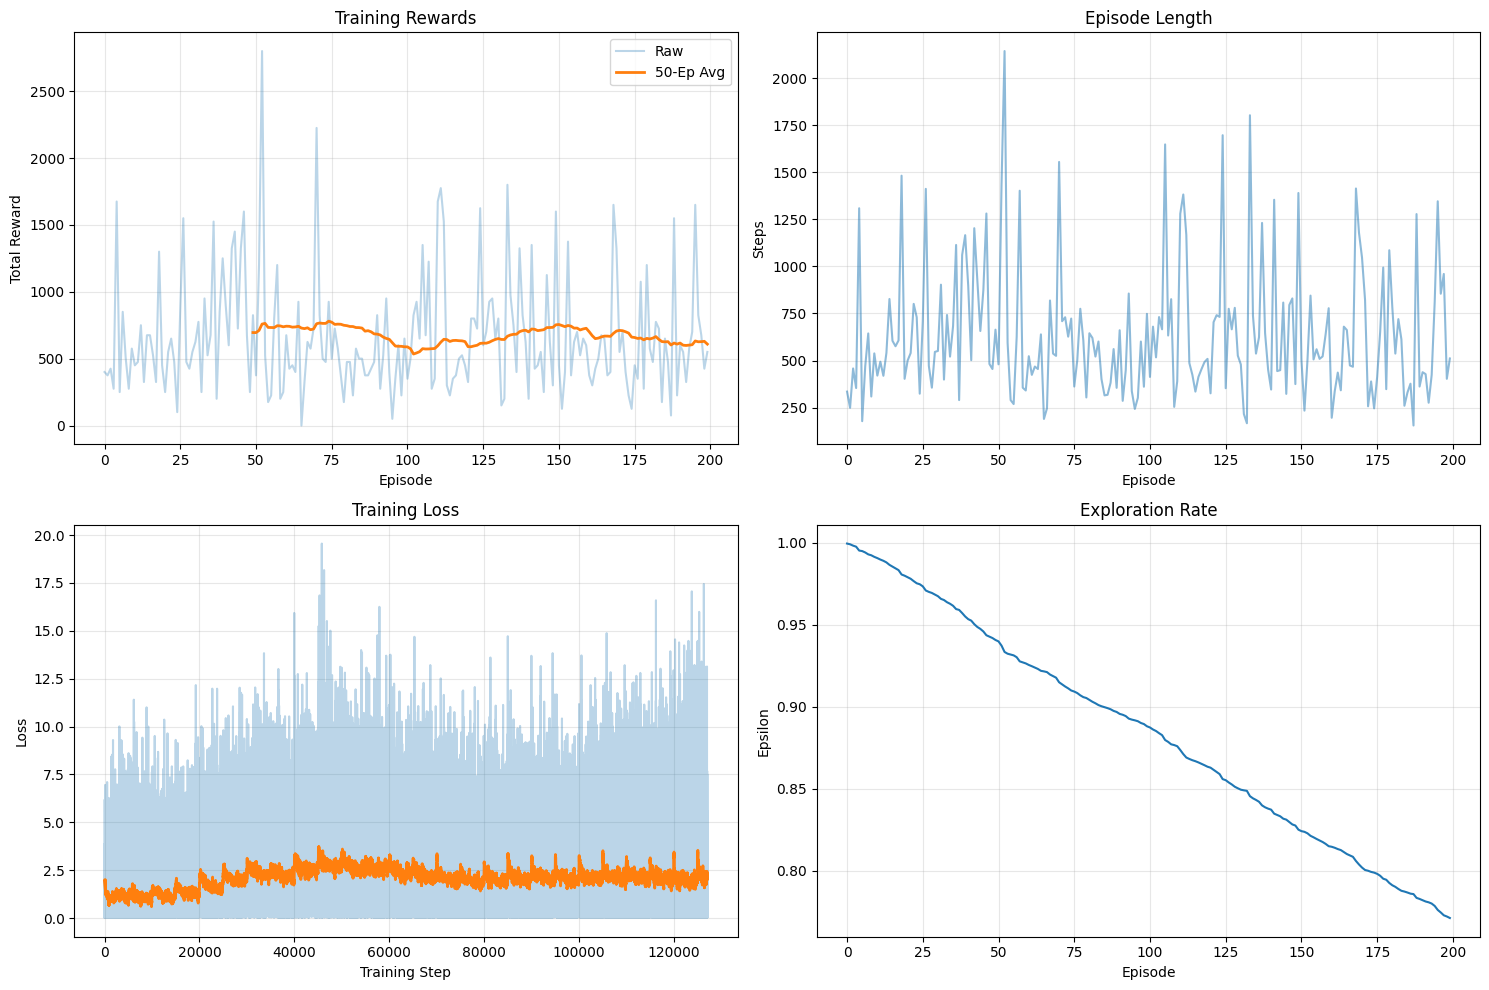

Agent saved to airraid_dqn_kaggle.pth

TRAINING COMPLETE!

Final Stats:
  Avg Reward (last 50): 608.50
  Total Steps: 127128
  Buffer Size: 50000

Test Performance:
  Avg Test Reward: 95.00


In [3]:
"""
Kaggle-Optimized Deep Q-Network for Air Raid
- Reduced training episodes for faster execution
- Automatic fallback for environment naming
- Kaggle-specific optimizations
"""

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import random
import matplotlib.pyplot as plt
from PIL import Image
import time

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])


class FramePreprocessor:
    """Preprocess Atari frames for DQN."""
    
    def __init__(self, height=84, width=84):
        self.height = height
        self.width = width
    
    def preprocess(self, frame):
        """Preprocess a single frame."""
        # Convert to grayscale
        if len(frame.shape) == 3:
            gray = np.dot(frame[..., :3], [0.299, 0.587, 0.114])
        else:
            gray = frame
        
        # Resize to 84x84
        img = Image.fromarray(gray.astype(np.uint8))
        img = img.resize((self.width, self.height), Image.BILINEAR)
        
        # Normalize to [0, 1]
        processed = np.array(img, dtype=np.float32) / 255.0
        
        return processed


class FrameStack:
    """Stack k consecutive frames."""
    
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)
    
    def reset(self):
        self.frames.clear()
    
    def push(self, frame):
        self.frames.append(frame)
        while len(self.frames) < self.k:
            self.frames.append(frame)
    
    def get_state(self):
        return np.stack(self.frames, axis=0)


class ReplayBuffer:
    """Experience Replay Buffer."""
    
    def __init__(self, capacity=50000):  # Reduced for Kaggle
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Experience(state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        experiences = random.sample(self.buffer, batch_size)
        
        states = torch.FloatTensor(np.array([e.state for e in experiences])).to(device)
        actions = torch.LongTensor([e.action for e in experiences]).to(device)
        rewards = torch.FloatTensor([e.reward for e in experiences]).to(device)
        next_states = torch.FloatTensor(np.array([e.next_state for e in experiences])).to(device)
        dones = torch.FloatTensor([e.done for e in experiences]).to(device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    """Deep Q-Network with CNN architecture."""
    
    def __init__(self, n_frames=4, n_actions=6):
        super(DQN, self).__init__()
        
        self.conv1 = nn.Conv2d(n_frames, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
        # Calculate conv output size
        def conv2d_size_out(size, kernel_size, stride):
            return (size - kernel_size) // stride + 1
        
        h = conv2d_size_out(conv2d_size_out(conv2d_size_out(84, 8, 4), 4, 2), 3, 1)
        w = conv2d_size_out(conv2d_size_out(conv2d_size_out(84, 8, 4), 4, 2), 3, 1)
        conv_output_size = h * w * 64
        
        self.fc1 = nn.Linear(conv_output_size, 512)
        self.fc2 = nn.Linear(512, n_actions)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        q_values = self.fc2(x)
        return q_values


class DQNAgent:
    """DQN Agent for Atari games."""
    
    def __init__(
        self,
        n_actions=6,
        learning_rate=0.00025,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.1,
        epsilon_decay_steps=500000,  # Reduced for Kaggle
        replay_buffer_size=50000,    # Reduced for Kaggle
        batch_size=32,
        target_update_frequency=5000,  # More frequent updates
        n_frames=4
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_frequency = target_update_frequency
        
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay_steps = epsilon_decay_steps
        self.epsilon = epsilon_start
        self.steps_done = 0
        
        # Networks
        self.policy_net = DQN(n_frames, n_actions).to(device)
        self.target_net = DQN(n_frames, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        # Optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)
        
        # Replay buffer
        self.replay_buffer = ReplayBuffer(replay_buffer_size)
        
        # Tracking
        self.episode_rewards = []
        self.episode_lengths = []
        self.losses = []
        self.epsilon_history = []
    
    def get_epsilon(self):
        epsilon = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
                  max(0, (self.epsilon_decay_steps - self.steps_done) / self.epsilon_decay_steps)
        return epsilon
    
    def select_action(self, state, training=True):
        if training:
            self.epsilon = self.get_epsilon()
            if random.random() < self.epsilon:
                return random.randrange(self.n_actions)
        
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.policy_net(state_tensor)
            return q_values.argmax().item()
    
    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        
        current_q_values = self.policy_net(states).gather(1, actions.unsqueeze(1))
        
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values
        
        loss = F.smooth_l1_loss(current_q_values.squeeze(), target_q_values)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()
        
        return loss.item()
    
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())
    
    def train(self, env, n_episodes=200, max_steps=5000):  # Reduced for Kaggle
        """Train the agent (Kaggle-optimized)."""
        preprocessor = FramePreprocessor()
        frame_stack = FrameStack(k=4)
        
        print(f"Training DQN for {n_episodes} episodes (Kaggle-optimized)...")
        print(f"Target update frequency: {self.target_update_frequency}")
        print()
        
        start_time = time.time()
        total_steps = 0
        
        for episode in range(n_episodes):
            frame, _ = env.reset()
            frame = preprocessor.preprocess(frame)
            frame_stack.reset()
            frame_stack.push(frame)
            state = frame_stack.get_state()
            
            episode_reward = 0
            episode_length = 0
            
            for step in range(max_steps):
                action = self.select_action(state, training=True)
                next_frame, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                
                next_frame = preprocessor.preprocess(next_frame)
                frame_stack.push(next_frame)
                next_state = frame_stack.get_state()
                
                self.replay_buffer.push(state, action, reward, next_state, done)
                
                loss = self.train_step()
                if loss is not None:
                    self.losses.append(loss)
                
                if total_steps % self.target_update_frequency == 0:
                    self.update_target_network()
                
                episode_reward += reward
                episode_length += 1
                total_steps += 1
                self.steps_done += 1
                state = next_state
                
                if done:
                    break
            
            self.episode_rewards.append(episode_reward)
            self.episode_lengths.append(episode_length)
            self.epsilon_history.append(self.epsilon)
            
            if (episode + 1) % 10 == 0:
                avg_reward = np.mean(self.episode_rewards[-10:])
                avg_length = np.mean(self.episode_lengths[-10:])
                avg_loss = np.mean(self.losses[-100:]) if self.losses else 0
                time_elapsed = time.time() - start_time
                
                print(f"Ep {episode + 1}/{n_episodes} | "
                      f"Steps: {total_steps} | "
                      f"Avg Reward: {avg_reward:.1f} | "
                      f"Avg Length: {avg_length:.0f} | "
                      f"Loss: {avg_loss:.4f} | "
                      f"ε: {self.epsilon:.3f} | "
                      f"Time: {time_elapsed:.0f}s")
        
        training_time = time.time() - start_time
        print(f"\nTraining completed in {training_time:.1f} seconds")
        return self.get_training_stats()
    
    def test(self, env, n_episodes=5):  # Reduced for Kaggle
        """Test the agent."""
        preprocessor = FramePreprocessor()
        frame_stack = FrameStack(k=4)
        
        print(f"\nTesting for {n_episodes} episodes...")
        test_rewards = []
        test_lengths = []
        
        for episode in range(n_episodes):
            frame, _ = env.reset()
            frame = preprocessor.preprocess(frame)
            frame_stack.reset()
            frame_stack.push(frame)
            state = frame_stack.get_state()
            
            episode_reward = 0
            episode_length = 0
            
            while True:
                action = self.select_action(state, training=False)
                next_frame, reward, terminated, truncated, _ = env.step(action)
                
                next_frame = preprocessor.preprocess(next_frame)
                frame_stack.push(next_frame)
                state = frame_stack.get_state()
                
                episode_reward += reward
                episode_length += 1
                
                if terminated or truncated:
                    break
            
            test_rewards.append(episode_reward)
            test_lengths.append(episode_length)
            
            print(f"Test Episode {episode + 1}: Reward = {episode_reward:.0f}, Length = {episode_length}")
        
        avg_reward = np.mean(test_rewards)
        avg_length = np.mean(test_lengths)
        
        print(f"\nTest Results:")
        print(f"  Average Reward: {avg_reward:.2f}")
        print(f"  Average Length: {avg_length:.2f}")
        
        return {
            'avg_reward': avg_reward,
            'avg_length': avg_length,
            'test_rewards': test_rewards,
            'test_lengths': test_lengths
        }
    
    def get_training_stats(self):
        return {
            'episode_rewards': self.episode_rewards,
            'episode_lengths': self.episode_lengths,
            'losses': self.losses,
            'epsilon_history': self.epsilon_history,
            'total_steps': self.steps_done,
            'avg_reward_last_50': np.mean(self.episode_rewards[-50:]) if len(self.episode_rewards) >= 50 else np.mean(self.episode_rewards),
            'buffer_size': len(self.replay_buffer)
        }
    
    def plot_training_progress(self):
        """Plot training metrics."""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Rewards
        axes[0, 0].plot(self.episode_rewards, alpha=0.3, label='Raw')
        if len(self.episode_rewards) >= 10:
            window = min(50, len(self.episode_rewards))
            rolling_avg = np.convolve(self.episode_rewards, 
                                     np.ones(window)/window, mode='valid')
            axes[0, 0].plot(range(window-1, len(self.episode_rewards)), 
                           rolling_avg, label=f'{window}-Ep Avg', linewidth=2)
        axes[0, 0].set_xlabel('Episode')
        axes[0, 0].set_ylabel('Total Reward')
        axes[0, 0].set_title('Training Rewards')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Episode lengths
        axes[0, 1].plot(self.episode_lengths, alpha=0.5)
        axes[0, 1].set_xlabel('Episode')
        axes[0, 1].set_ylabel('Steps')
        axes[0, 1].set_title('Episode Length')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Loss
        if self.losses:
            axes[1, 0].plot(self.losses, alpha=0.3)
            if len(self.losses) >= 100:
                rolling_avg = np.convolve(self.losses, np.ones(100)/100, mode='valid')
                axes[1, 0].plot(range(99, len(self.losses)), rolling_avg, linewidth=2)
            axes[1, 0].set_xlabel('Training Step')
            axes[1, 0].set_ylabel('Loss')
            axes[1, 0].set_title('Training Loss')
            axes[1, 0].grid(True, alpha=0.3)
        
        # Epsilon
        axes[1, 1].plot(self.epsilon_history)
        axes[1, 1].set_xlabel('Episode')
        axes[1, 1].set_ylabel('Epsilon')
        axes[1, 1].set_title('Exploration Rate')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    def save(self, filepath='airraid_dqn.pth'):
        """Save the trained agent."""
        torch.save({
            'policy_net': self.policy_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'episode_rewards': self.episode_rewards,
            'steps_done': self.steps_done
        }, filepath)
        print(f"Agent saved to {filepath}")


def create_environment():
    """Create Air Raid environment with fallback options."""
    env_names = [
        'ALE/AirRaid-v5',
        'AirRaid-v5',
        'ALE/AirRaid-v4',
        'AirRaid-v4'
    ]
    
    for env_name in env_names:
        try:
            print(f"Trying to create environment: {env_name}")
            env = gym.make(env_name, frameskip=4)
            print(f"✓ Successfully created: {env_name}")
            print(f"  Action space: {env.action_space}")
            print(f"  Observation space: {env.observation_space}")
            return env
        except Exception as e:
            print(f"✗ Failed: {e}")
            continue
    
    raise RuntimeError("Could not create Air Raid environment. Please run the setup cell first.")


# Main execution
if __name__ == "__main__":
    print("="*70)
    print("KAGGLE-OPTIMIZED DQN FOR AIR RAID")
    print("="*70)
    print()
    
    # Create environment
    env = create_environment()
    print()
    
    # Create agent
    agent = DQNAgent(
        n_actions=env.action_space.n,
        learning_rate=0.00025,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.1,
        epsilon_decay_steps=500000,
        replay_buffer_size=50000,
        batch_size=32,
        target_update_frequency=5000,
        n_frames=4
    )
    
    # Train (reduced episodes for Kaggle)
    print("Starting training...")
    stats = agent.train(env, n_episodes=200, max_steps=5000)
    
    # Test
    test_stats = agent.test(env, n_episodes=5)
    
    # Plot
    agent.plot_training_progress()
    
    # Save
    agent.save('airraid_dqn_kaggle.pth')
    
    env.close()
    
    print("\n" + "="*70)
    print("TRAINING COMPLETE!")
    print("="*70)
    print(f"\nFinal Stats:")
    print(f"  Avg Reward (last 50): {stats['avg_reward_last_50']:.2f}")
    print(f"  Total Steps: {stats['total_steps']}")
    print(f"  Buffer Size: {stats['buffer_size']}")
    print(f"\nTest Performance:")
    print(f"  Avg Test Reward: {test_stats['avg_reward']:.2f}")